<a href="https://colab.research.google.com/github/Nkeh/ml-algorithms/blob/main/decision_tree_loan_approval.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Problem 3: Loan Approval Prediction — Decision Tree

**Course ML Project | Model 3 of 4**

---

### Pipeline
1. Scope & Problem Definition
2. Data Acquisition
3. Cleaning & Preprocessing
4. Exploratory Data Analysis (EDA)
5. Feature Engineering
6. **Model Selection** ← the key step
7. Model Training
8. Evaluation & Tuning
9. PCA Extension

---
## Step 1 — Scope & Problem Definition

**Goal:** Predict whether a loan application should be approved (Y) or rejected (N) based on applicant information.

| Property | Detail |
|---|---|
| Task type | Supervised **binary classification** |
| Target variable | `Loan_Status` — Y (approved) or N (rejected) |
| Input features | Mix of categorical (gender, education, property area) and numerical (income, loan amount) |
| Dataset | Loan Prediction Dataset — 614 applications, 12 features |

### Why this problem calls for a Decision Tree

Loan approval decisions are fundamentally **rule-based**:
> *"If credit history is good AND income exceeds threshold AND loan amount is reasonable → Approve"*

This is exactly what a decision tree encodes. At each internal node it asks one yes/no question about a feature; the path from root to leaf is the decision rule. This mirrors how a loan officer actually thinks — making it both powerful and **interpretable**, which is critical in financial applications (regulators often require explainable decisions).

The dataset also has a mix of **categorical and numeric features** — decision trees handle both natively without needing dummy encoding or scaling, unlike logistic regression or KNN.

---
## Step 2 — Data Acquisition

We use the **Loan Prediction Dataset** — a widely used teaching dataset for classification on mixed-type features.

| Feature | Type | Description |
|---|---|---|
| `Gender` | Categorical | Male / Female |
| `Married` | Categorical | Yes / No |
| `Dependents` | Categorical | 0, 1, 2, 3+ |
| `Education` | Categorical | Graduate / Not Graduate |
| `Self_Employed` | Categorical | Yes / No |
| `ApplicantIncome` | Numeric | Monthly income of applicant |
| `CoapplicantIncome` | Numeric | Monthly income of co-applicant |
| `LoanAmount` | Numeric | Loan amount in thousands |
| `Loan_Amount_Term` | Numeric | Term in months |
| `Credit_History` | Binary | 1 = good credit history, 0 = bad |
| `Property_Area` | Categorical | Urban / Semiurban / Rural |
| `Loan_Status` | **Target** | Y = Approved, N = Rejected |

In [ ]:
# ── Imports ───────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11
})

BLUE  = '#378ADD'
CORAL = '#D85A30'
TEAL  = '#1D9E75'
AMBER = '#BA7517'
PURP  = '#7F77DD'
GRAY  = '#888780'

print('Libraries loaded.')

Libraries loaded.


In [ ]:
# ── Load data ─────────────────────────────────────────────────────────────────
URL = 'https://raw.githubusercontent.com/shrikant-temburwar/Loan-Prediction-Dataset/master/train.csv'
df_raw = pd.read_csv(URL)

print(f'Shape: {df_raw.shape}')
print(f'\nClass balance:')
print(df_raw['Loan_Status'].value_counts())
print(f'\nMissing values per column:')
print(df_raw.isnull().sum())
df_raw.head()

Shape: (614, 13)

Class balance:
Loan_Status
Y    422
N    192
Name: count, dtype: int64

Missing values per column:
Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


---
## Step 3 — Cleaning & Preprocessing

**Issues to address:**

1. **Missing values** — `Credit_History` (50), `Self_Employed` (32), `LoanAmount` (22), `Dependents` (15), `Loan_Amount_Term` (14), `Gender` (13), `Married` (3). Numeric missing → median; categorical missing → mode.
2. **`Dependents` column** — contains `'3+'` as a string; we map it to `3`.
3. **Target encoding** — convert `Loan_Status` from `Y/N` to `1/0`.
4. **Categorical encoding** — label-encode binary categoricals; one-hot encode multi-category ones.
5. **Class imbalance** — 422 approved (68.7%) vs 192 rejected (31.3%). We use `class_weight='balanced'`.

**Note:** Decision trees do not require feature scaling — splits are based on thresholds, not distances or dot products. We skip `StandardScaler` here.

In [ ]:
# ── Preprocessing ─────────────────────────────────────────────────────────────
df = df_raw.drop(columns=['Loan_ID']).copy()

# Fix Dependents '3+' → 3
df['Dependents'] = df['Dependents'].replace('3+', '3').astype(float)

# Encode target: Y → 1, N → 0
df['Loan_Status'] = (df['Loan_Status'] == 'Y').astype(int)

# Separate column types
cat_cols = ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area']
num_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
            'Loan_Amount_Term', 'Credit_History', 'Dependents']

# Impute missing values
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print(f'Missing values after imputation: {df.isnull().sum().sum()}')

# Encode binary categoricals
df['Gender']       = (df['Gender']       == 'Male').astype(int)
df['Married']      = (df['Married']      == 'Yes').astype(int)
df['Education']    = (df['Education']    == 'Graduate').astype(int)
df['Self_Employed']= (df['Self_Employed']== 'Yes').astype(int)

# One-hot encode Property_Area
df = pd.get_dummies(df, columns=['Property_Area'], drop_first=True)

print(f'Final shape: {df.shape}')
print(f'Class balance: {df["Loan_Status"].value_counts().to_dict()}')
df.head()

Missing values after imputation: 0
Final shape: (614, 13)
Class balance: {1: 422, 0: 192}


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Property_Area_Semiurban,Property_Area_Urban
0,1,0,0.0,1,0,5849,0.0,128.0,360.0,1.0,1,False,True
1,1,1,1.0,1,0,4583,1508.0,128.0,360.0,1.0,0,False,False
2,1,1,0.0,1,1,3000,0.0,66.0,360.0,1.0,1,False,True
3,1,1,0.0,0,0,2583,2358.0,120.0,360.0,1.0,1,False,True
4,1,0,0.0,1,0,6000,0.0,141.0,360.0,1.0,1,False,True


---
## Step 4 — Exploratory Data Analysis (EDA)

We look at how each feature relates to loan approval, focusing on both numeric distributions and categorical approval rates.

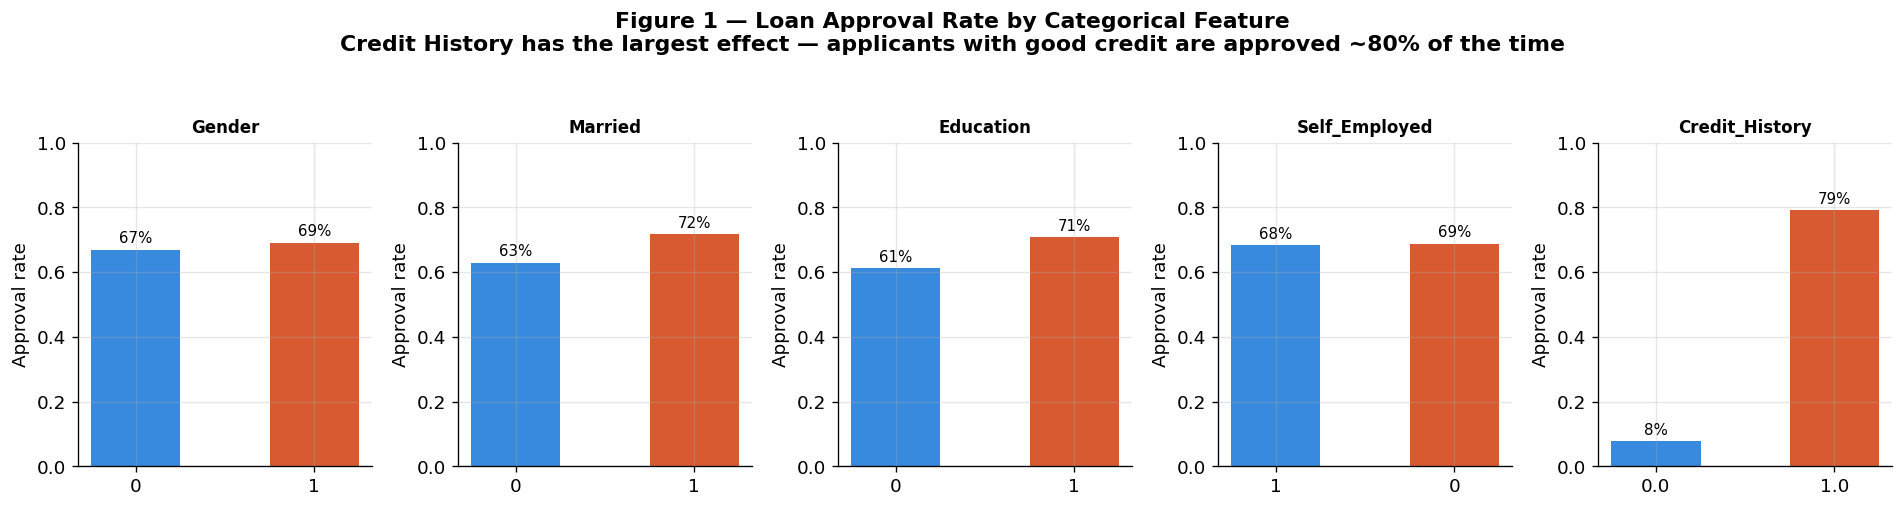

In [ ]:
# ── 4a. Approval rate by categorical features ─────────────────────────────────
cat_orig = ['Gender', 'Married', 'Education', 'Self_Employed', 'Credit_History']

fig, axes = plt.subplots(1, 5, figsize=(16, 4))
for ax, col in zip(axes, cat_orig):
    rates = df.groupby(col)['Loan_Status'].mean().sort_values()
    ax.bar(rates.index.astype(str), rates.values,
           color=[BLUE, CORAL] if len(rates)==2 else [BLUE, TEAL, CORAL],
           edgecolor='none', width=0.5)
    ax.set_title(col, fontweight='bold', fontsize=10)
    ax.set_ylabel('Approval rate')
    ax.set_ylim(0, 1)
    for i, v in enumerate(rates.values):
        ax.text(i, v + 0.02, f'{v:.0%}', ha='center', fontsize=9)

plt.suptitle('Figure 1 — Loan Approval Rate by Categorical Feature\n'
             'Credit History has the largest effect — applicants with good credit are approved ~80% of the time',
             fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

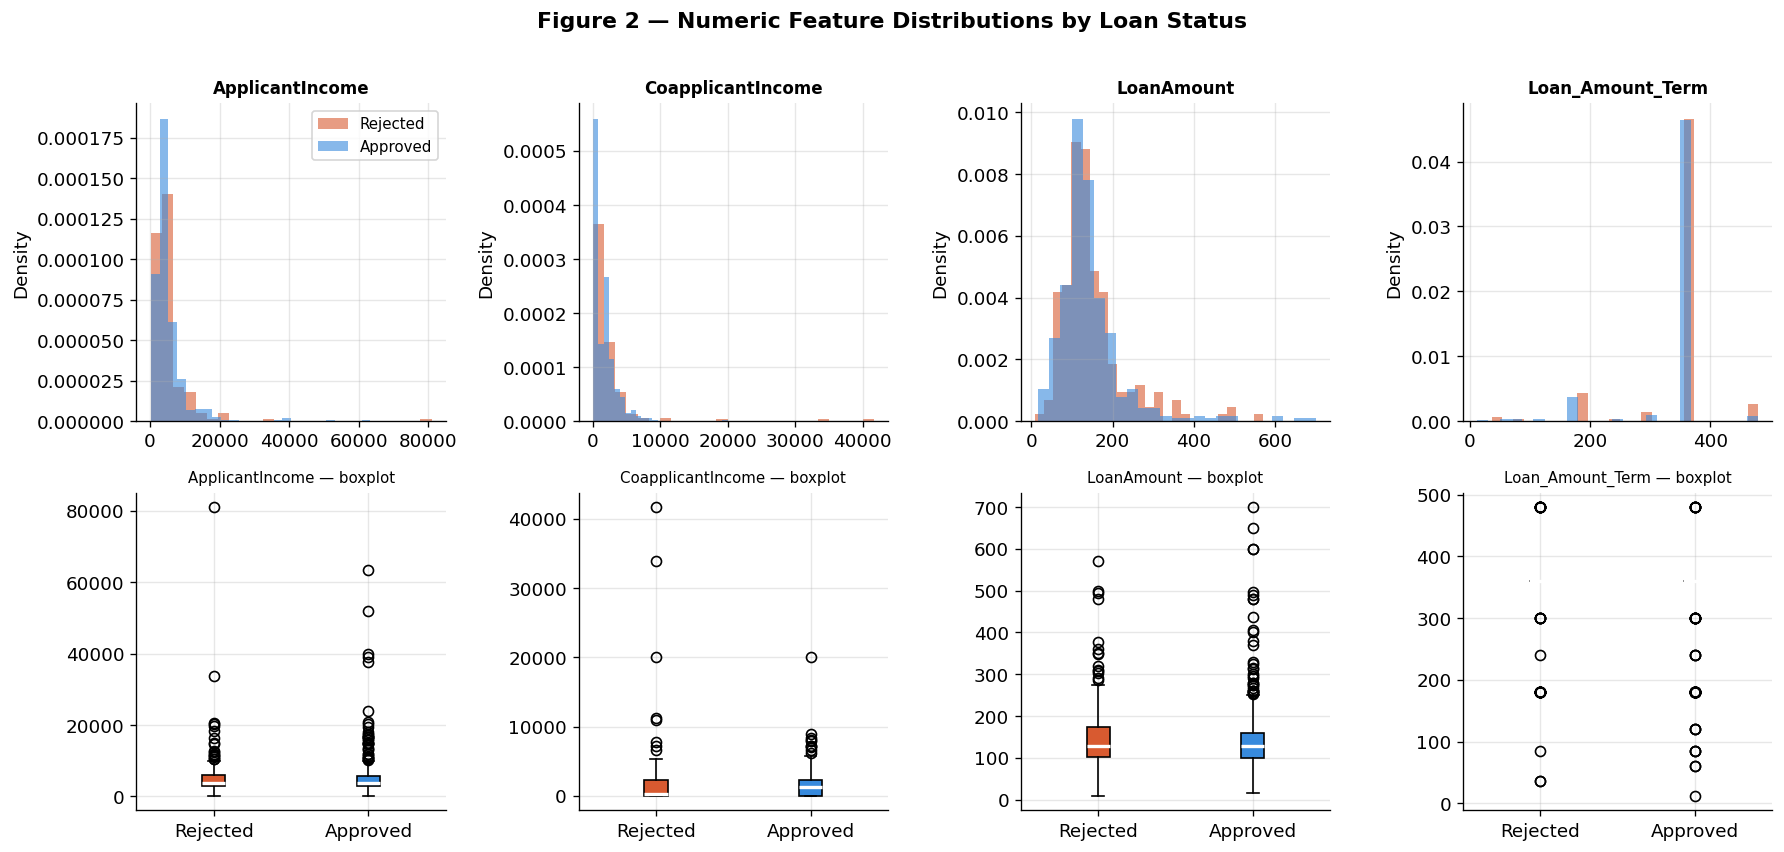

In [ ]:
# ── 4b. Numeric feature distributions by loan status ─────────────────────────
num_plot = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']

fig, axes = plt.subplots(2, 4, figsize=(15, 7))
for i, feat in enumerate(num_plot):
    # Histogram
    axes[0, i].hist(df[df['Loan_Status']==0][feat], bins=25, alpha=0.6,
                    color=CORAL, label='Rejected', density=True)
    axes[0, i].hist(df[df['Loan_Status']==1][feat], bins=25, alpha=0.6,
                    color=BLUE, label='Approved', density=True)
    axes[0, i].set_title(feat, fontweight='bold', fontsize=10)
    axes[0, i].set_ylabel('Density')
    if i == 0:
        axes[0, i].legend(fontsize=9)
    # Boxplot
    data_box = [df[df['Loan_Status']==0][feat], df[df['Loan_Status']==1][feat]]
    bp = axes[1, i].boxplot(data_box, patch_artist=True,
                             medianprops={'color':'white','linewidth':2})
    bp['boxes'][0].set_facecolor(CORAL)
    bp['boxes'][1].set_facecolor(BLUE)
    axes[1, i].set_xticklabels(['Rejected', 'Approved'])
    axes[1, i].set_title(f'{feat} — boxplot', fontsize=9)

plt.suptitle('Figure 2 — Numeric Feature Distributions by Loan Status',
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

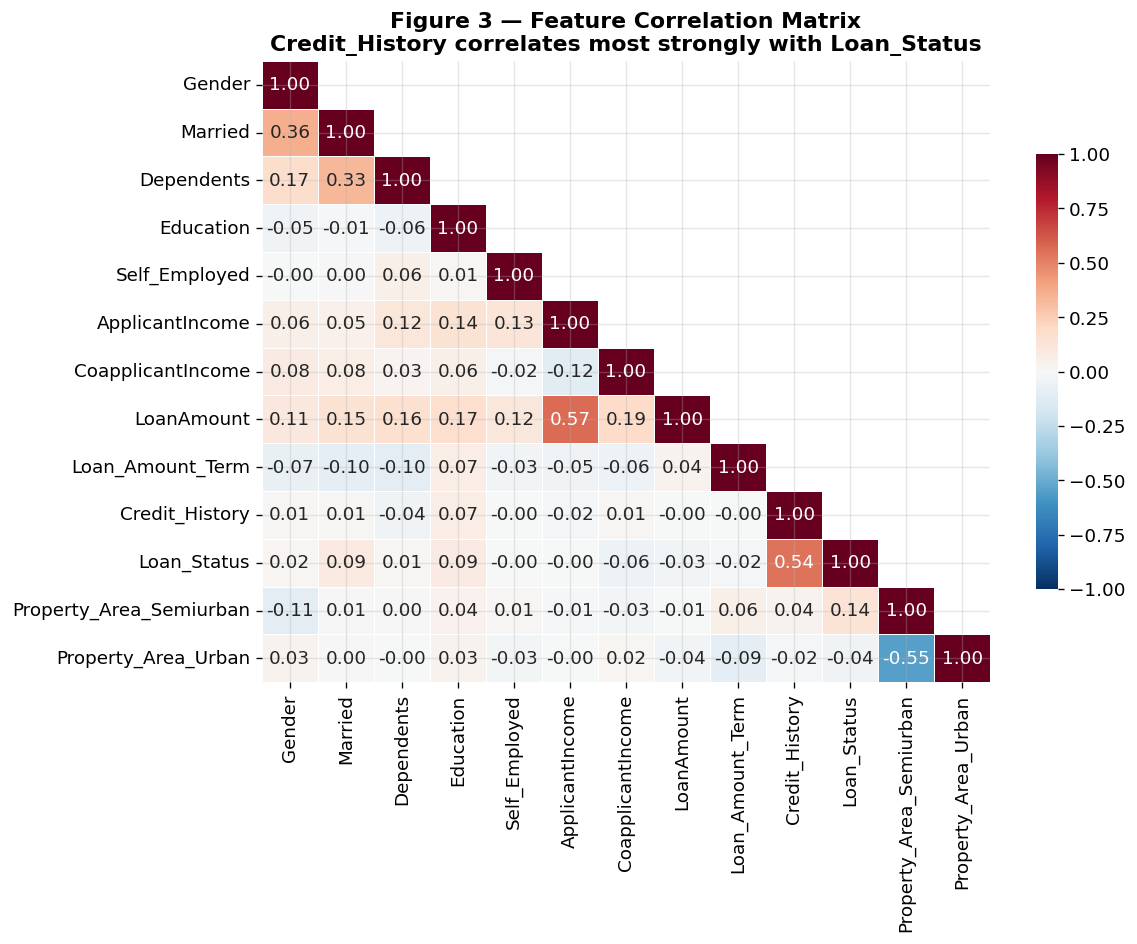

In [ ]:
# ── 4c. Correlation heatmap ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.7})
ax.set_title('Figure 3 — Feature Correlation Matrix\n'
             'Credit_History correlates most strongly with Loan_Status',
             fontweight='bold')
plt.tight_layout()
plt.show()

---
## Step 5 — Feature Engineering

We create features that capture the financial ratios a loan officer would intuitively assess:

| New Feature | Formula | Rationale |
|---|---|---|
| `TotalIncome` | `ApplicantIncome + CoapplicantIncome` | Combined household earning power |
| `LogTotalIncome` | `log(TotalIncome + 1)` | Income is right-skewed; log compresses it |
| `LogLoanAmount` | `log(LoanAmount + 1)` | Loan amount is also right-skewed |
| `EMI` | `LoanAmount / Loan_Amount_Term` | Estimated monthly installment |
| `DebtIncomeRatio` | `LoanAmount / (TotalIncome + 1)` | How large is the loan relative to income? Higher = riskier |
| `IncomePerDependent` | `TotalIncome / (Dependents + 1)` | Effective income per household member |

In [ ]:
# ── Feature engineering ───────────────────────────────────────────────────────
df['TotalIncome']        = df['ApplicantIncome'] + df['CoapplicantIncome']
df['LogTotalIncome']     = np.log(df['TotalIncome'] + 1)
df['LogLoanAmount']      = np.log(df['LoanAmount'] + 1)
df['EMI']                = df['LoanAmount'] / (df['Loan_Amount_Term'] + 1)
df['DebtIncomeRatio']    = df['LoanAmount'] / (df['TotalIncome'] + 1)
df['IncomePerDependent'] = df['TotalIncome'] / (df['Dependents'] + 1)

FEATURES = [c for c in df.columns if c != 'Loan_Status']
print(f'Total features after engineering: {len(FEATURES)}')
print(FEATURES)

# Verify new features correlate with target
new_feats = ['TotalIncome', 'LogTotalIncome', 'LogLoanAmount',
             'EMI', 'DebtIncomeRatio', 'IncomePerDependent']
print('\nCorrelation of new features with Loan_Status:')
for f in new_feats:
    print(f'  {f:<25} {df[f].corr(df["Loan_Status"]):+.3f}')

Total features after engineering: 18
['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area_Semiurban', 'Property_Area_Urban', 'TotalIncome', 'LogTotalIncome', 'LogLoanAmount', 'EMI', 'DebtIncomeRatio', 'IncomePerDependent']

Correlation of new features with Loan_Status:
  TotalIncome               -0.031
  LogTotalIncome            +0.007
  LogLoanAmount             -0.038
  EMI                       -0.013
  DebtIncomeRatio           -0.086
  IncomePerDependent        -0.022


---
## Step 6 — Model Selection (the key step)

### Why a Decision Tree?

### 6.1 — The structure of the problem demands rule-based splits

Loan approval is a **conditional, rule-based decision**. The data has a mix of categorical and numeric features. A decision tree models exactly this: at each node it partitions the data using the single best feature and threshold.

Compare this to logistic regression, which produces a **global linear boundary**:
$$P(Y=1) = \sigma(w_1 x_1 + w_2 x_2 + \cdots + w_p x_p + b)$$

If the true boundary is non-linear — e.g., low income is fine *if* credit history is good — logistic regression cannot capture this interaction without manual feature engineering. The decision tree captures it naturally.

### 6.2 — Splitting criterion: Gini Impurity

At each node, the tree chooses the feature and threshold that **maximally reduces impurity**. We use the **Gini impurity**:

$$\text{Gini}(S) = 1 - \sum_{k=1}^{K} p_k^2$$

where $p_k$ is the proportion of class $k$ in node $S$.

- Pure node (all one class): $\text{Gini} = 1 - 1^2 = 0$ ← perfect
- Perfectly mixed node (50/50): $\text{Gini} = 1 - (0.5^2 + 0.5^2) = 0.5$ ← worst

The **Gini gain** from a split at threshold $t$ on feature $j$:

$$\Delta\text{Gini} = \text{Gini}(S) - \frac{|S_L|}{|S|}\text{Gini}(S_L) - \frac{|S_R|}{|S|}\text{Gini}(S_R)$$

The tree greedily picks the $(j, t)$ pair that maximises $\Delta\text{Gini}$ at each step.

### 6.3 — Alternative: Information Gain (Entropy)

Instead of Gini, we can use **entropy**:

$$H(S) = -\sum_{k=1}^{K} p_k \log_2(p_k)$$

$$\text{Information Gain} = H(S) - \frac{|S_L|}{|S|}H(S_L) - \frac{|S_R|}{|S|}H(S_R)$$

Gini is faster to compute (no logarithm) and tends to isolate the most frequent class. Entropy is more balanced. In practice their results are nearly identical — we use Gini.

### 6.4 — Why not the other models?

| Model | Why it doesn't fit as well |
|---|---|
| Linear Regression | Continuous output; can't classify |
| Logistic Regression | Linear boundary only; can't capture feature interactions without manual engineering |
| KNN | No interpretable rules; distance-based so needs scaling; every prediction requires the full training set |

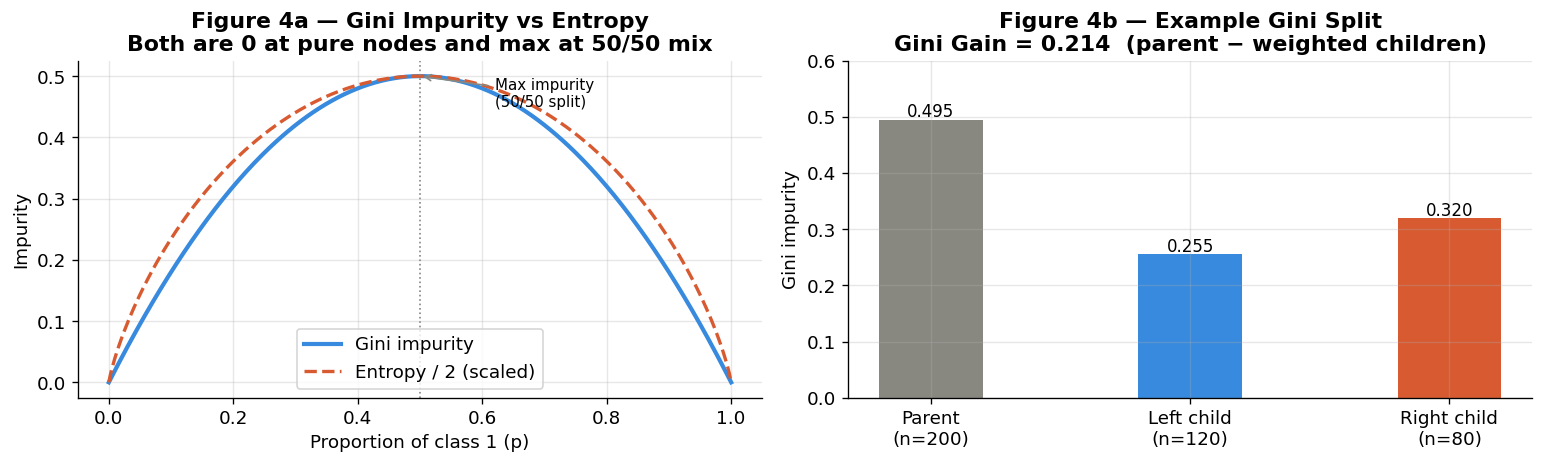

Parent  Gini: 0.4950  (p=0.45)
Left    Gini: 0.2550  (p=0.85, n=120)
Right   Gini: 0.3200  (p=0.2, n=80)
Gini Gain:    0.2140  ← the tree maximises this at every node


In [ ]:
# ── 6a. Visualise Gini impurity ───────────────────────────────────────────────
p = np.linspace(0, 1, 400)
gini    = 1 - p**2 - (1-p)**2
entropy = -np.where(p==0, 0, p*np.log2(np.where(p==0, 1, p))) \
          -np.where(p==1, 0, (1-p)*np.log2(np.where(p==1, 1, 1-p)))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(p, gini,    color=BLUE,  linewidth=2.5, label='Gini impurity')
axes[0].plot(p, entropy/2, color=CORAL, linewidth=2,
             linestyle='--', label='Entropy / 2 (scaled)')
axes[0].axvline(0.5, color=GRAY, linewidth=1, linestyle=':')
axes[0].annotate('Max impurity\n(50/50 split)', xy=(0.5, 0.5),
                  xytext=(0.62, 0.45), fontsize=9,
                  arrowprops=dict(arrowstyle='->', color=GRAY))
axes[0].set_title('Figure 4a — Gini Impurity vs Entropy\n'
                  'Both are 0 at pure nodes and max at 50/50 mix',
                  fontweight='bold')
axes[0].set_xlabel('Proportion of class 1 (p)')
axes[0].set_ylabel('Impurity')
axes[0].legend()

# Illustrate one split
parent_p = 0.45        # 45% approved in parent node
left_p   = 0.85        # mostly approved on left
right_p  = 0.20        # mostly rejected on right
n_left, n_right = 120, 80
n_total = n_left + n_right

gini_parent = 1 - parent_p**2 - (1-parent_p)**2
gini_left   = 1 - left_p**2   - (1-left_p)**2
gini_right  = 1 - right_p**2  - (1-right_p)**2
gini_gain   = gini_parent - (n_left/n_total)*gini_left - (n_right/n_total)*gini_right

nodes = ['Parent\n(n=200)', 'Left child\n(n=120)', 'Right child\n(n=80)']
impurities = [gini_parent, gini_left, gini_right]
colors_bar = [GRAY, BLUE, CORAL]

bars = axes[1].bar(nodes, impurities, color=colors_bar, edgecolor='none', width=0.4)
for bar, val in zip(bars, impurities):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.005,
                 f'{val:.3f}', ha='center', fontsize=10, fontweight='500')
axes[1].set_title(f'Figure 4b — Example Gini Split\n'
                  f'Gini Gain = {gini_gain:.3f}  '
                  f'(parent − weighted children)',
                  fontweight='bold')
axes[1].set_ylabel('Gini impurity')
axes[1].set_ylim(0, 0.60)

plt.tight_layout()
plt.show()

print(f'Parent  Gini: {gini_parent:.4f}  (p={parent_p})')
print(f'Left    Gini: {gini_left:.4f}  (p={left_p}, n={n_left})')
print(f'Right   Gini: {gini_right:.4f}  (p={right_p}, n={n_right})')
print(f'Gini Gain:    {gini_gain:.4f}  ← the tree maximises this at every node')

---
## Step 7 — Model Training

Key decisions:
- **No scaling needed** — decision trees split on ordered thresholds, not distances. `StandardScaler` would not change the tree structure.
- **`class_weight='balanced'`** — handles the 68/32 class imbalance.
- **`max_depth`** — controls tree complexity. An unlimited tree will overfit; we tune this.
- **Stratified split** — ensures both train and test have the same class ratio.

In [ ]:
from sklearn.tree         import DecisionTreeClassifier, export_text, plot_tree
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics      import (accuracy_score, classification_report,
                                   confusion_matrix, roc_auc_score,
                                   roc_curve, ConfusionMatrixDisplay)

X = df[FEATURES]
y = df['Loan_Status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f'Training: {len(X_train)} | Test: {len(X_test)}')
print(f'Train approval rate: {y_train.mean():.3f}')
print(f'Test  approval rate: {y_test.mean():.3f}')

Training: 491 | Test: 123
Train approval rate: 0.686
Test  approval rate: 0.691


In [ ]:
# ── Train initial tree (max_depth=4 for interpretability) ─────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

dt = DecisionTreeClassifier(
    criterion='gini',
    max_depth=4,
    class_weight='balanced',
    random_state=42
)
dt.fit(X_train, y_train)

cv_acc = cross_val_score(dt, X_train, y_train, cv=cv, scoring='accuracy')
cv_auc = cross_val_score(dt, X_train, y_train, cv=cv, scoring='roc_auc')
cv_f1  = cross_val_score(dt, X_train, y_train, cv=cv, scoring='f1')

print('5-fold CV on training set (max_depth=4):')
print(f'  Accuracy : {cv_acc.mean():.4f} ± {cv_acc.std():.4f}')
print(f'  ROC-AUC  : {cv_auc.mean():.4f} ± {cv_auc.std():.4f}')
print(f'  F1 Score : {cv_f1.mean():.4f}  ± {cv_f1.std():.4f}')

5-fold CV on training set (max_depth=4):
  Accuracy : 0.7311 ± 0.0784
  ROC-AUC  : 0.6687 ± 0.0958
  F1 Score : 0.8112  ± 0.0598


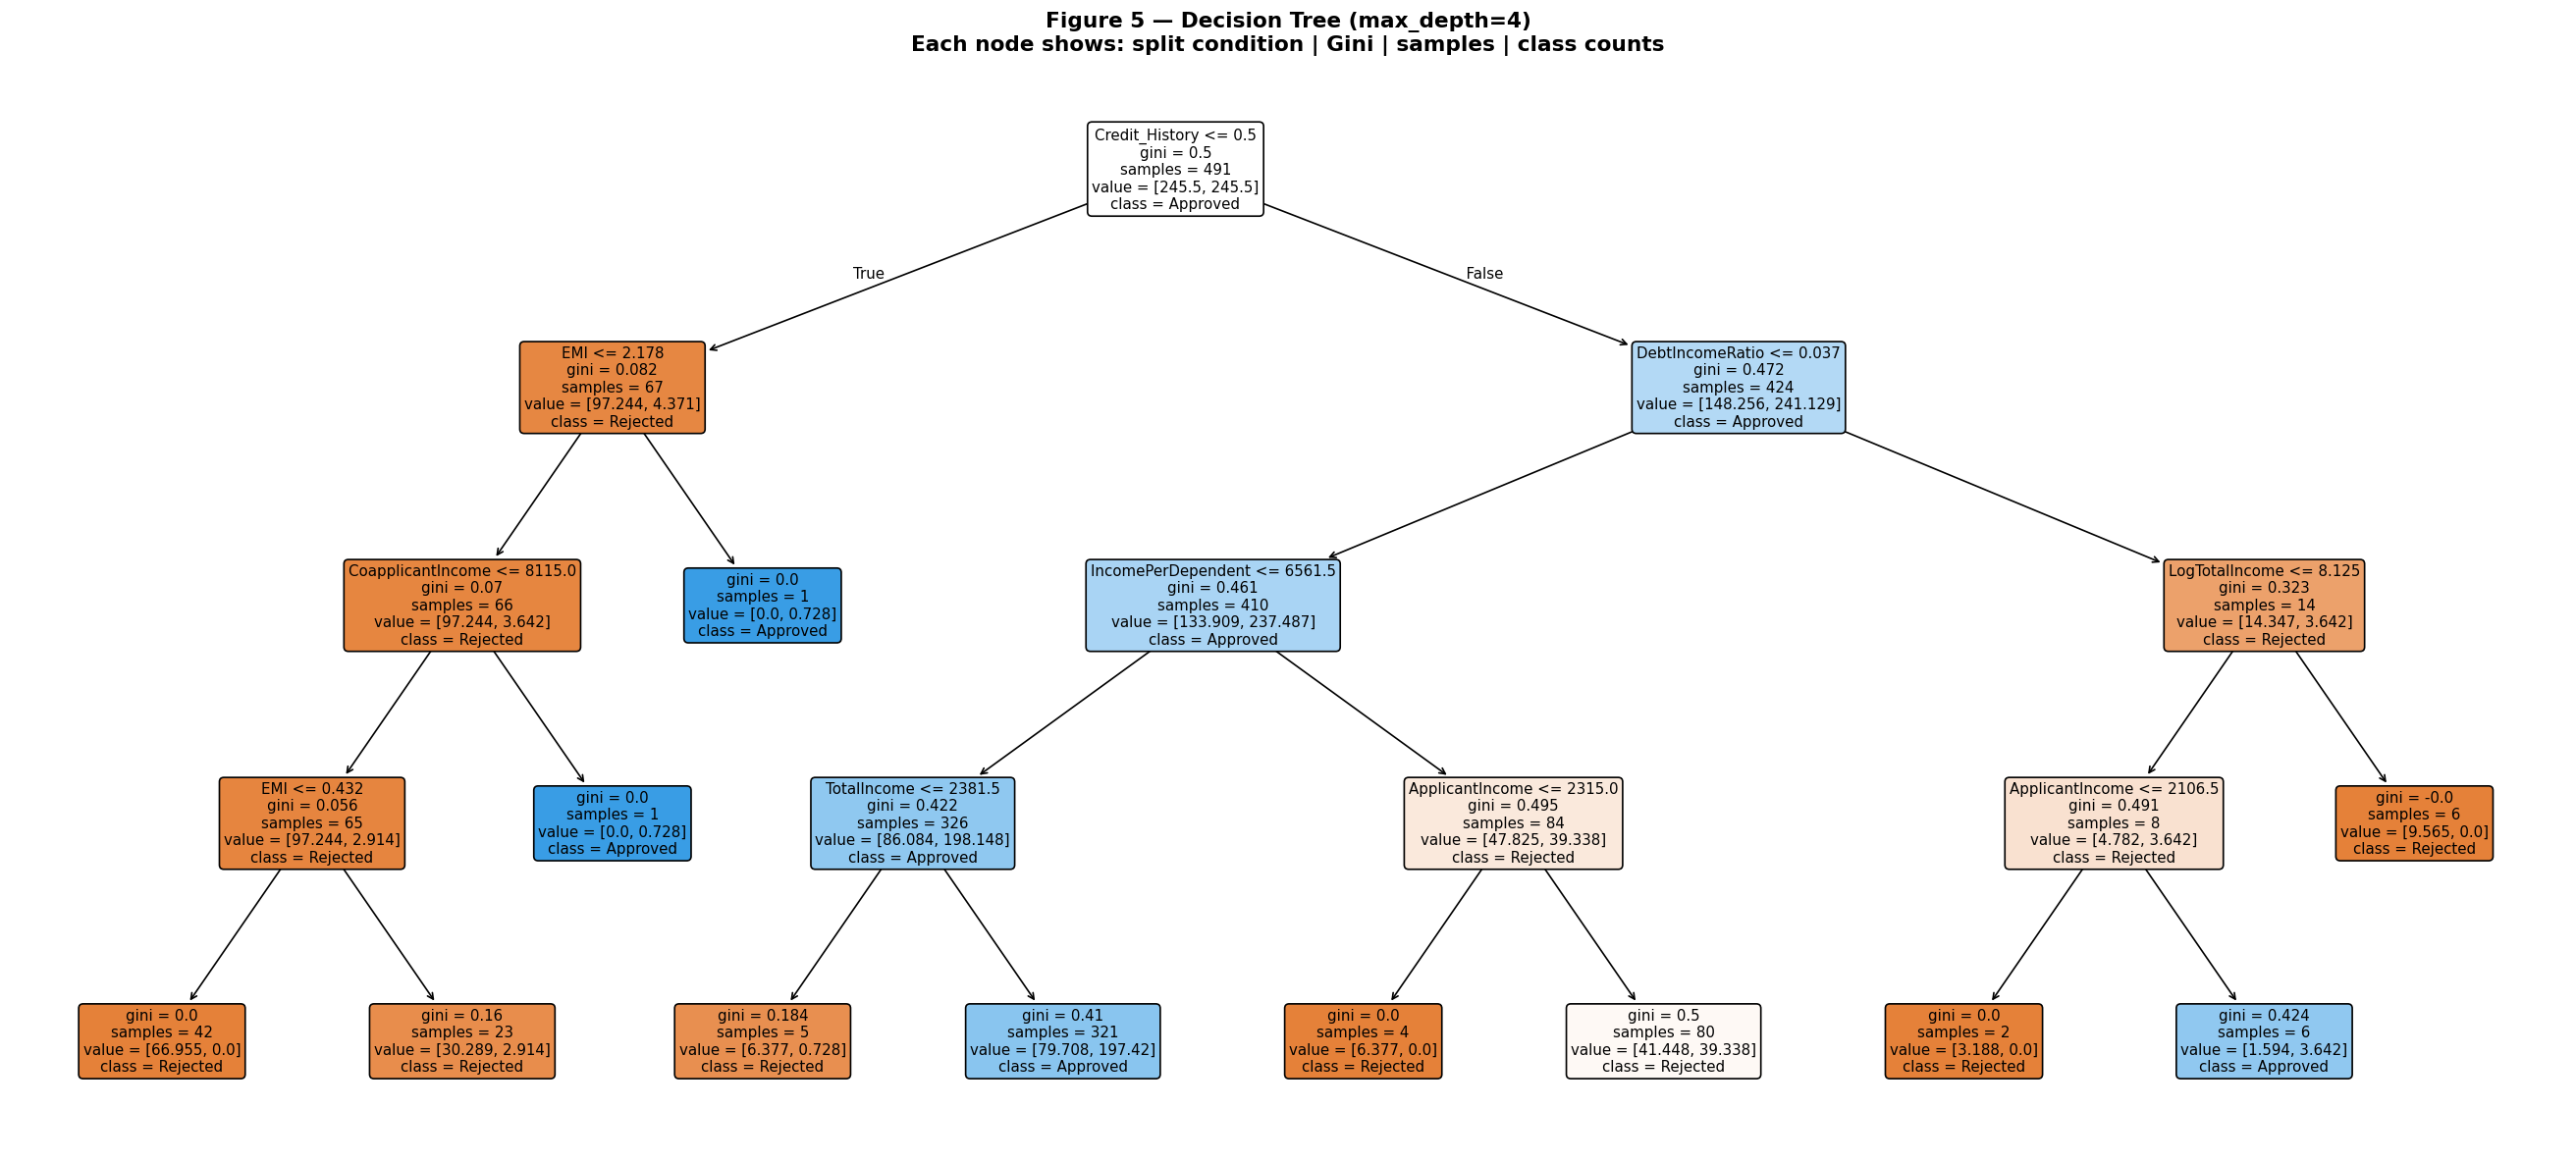


Decision rules (text format):
|--- Credit_History <= 0.50
|   |--- EMI <= 2.18
|   |   |--- CoapplicantIncome <= 8115.00
|   |   |   |--- EMI <= 0.43
|   |   |   |   |--- class: 0
|   |   |   |--- EMI >  0.43
|   |   |   |   |--- class: 0
|   |   |--- CoapplicantIncome >  8115.00
|   |   |   |--- class: 1
|   |--- EMI >  2.18
|   |   |--- class: 1
|--- Credit_History >  0.50
|   |--- DebtIncomeRatio <= 0.04
|   |   |--- IncomePerDependent <= 6561.50
|   |   |   |--- TotalIncome <= 2381.50
|   |   |   |   |--- class: 0
|   |   |   |--- TotalIncome >  2381.50
|   |   |   |   |--- class: 1
|   |   |--- IncomePerDependent >  6561.50
|   |   |   |--- ApplicantIncome <= 2315.00
|   |   |   |   |--- class: 0
|   |   |   |--- ApplicantIncome >  2315.00
|   |   |   |   |--- class: 0
|   |--- DebtIncomeRatio >  0.04
|   |   |--- LogTotalIncome <= 8.13
|   |   |   |--- ApplicantIncome <= 2106.50
|   |   |   |   |--- class: 0
|   |   |   |--- ApplicantIncome >  2106.50
|   |   |   |   |--- class:

In [ ]:
# ── Figure 5: Visualise the actual decision tree ──────────────────────────────
# This is the most important visualisation — it shows the actual learned rules
fig, ax = plt.subplots(figsize=(22, 10))
plot_tree(
    dt,
    feature_names=FEATURES,
    class_names=['Rejected', 'Approved'],
    filled=True,
    rounded=True,
    impurity=True,
    proportion=False,
    fontsize=9,
    ax=ax
)
ax.set_title('Figure 5 — Decision Tree (max_depth=4)\n'
             'Each node shows: split condition | Gini | samples | class counts',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

# Print the tree as text rules
print('\nDecision rules (text format):')
print(export_text(dt, feature_names=FEATURES))

---
## Step 8 — Evaluation & Tuning

We evaluate on the test set, then tune `max_depth` — the most important hyperparameter for decision trees. A shallow tree underfits (high bias); a deep tree memorises training data (high variance). The bias-variance tradeoff:

$$\text{Total Error} = \underbrace{\text{Bias}^2}_{\text{underfitting}} + \underbrace{\text{Variance}}_{\text{overfitting}} + \underbrace{\text{Irreducible noise}}_{\text{fixed}}$$

We also tune `min_samples_split` and `min_samples_leaf` — these prevent the tree from creating splits on very few samples (a sign of overfitting).

In [ ]:
# ── Test set evaluation (depth=4 model) ───────────────────────────────────────
y_pred = dt.predict(X_test)
y_prob = dt.predict_proba(X_test)[:, 1]

print('Test set performance (max_depth=4):')
print(f'  Accuracy : {accuracy_score(y_test, y_pred):.4f}')
print(f'  ROC-AUC  : {roc_auc_score(y_test, y_prob):.4f}')
print()
print(classification_report(y_test, y_pred,
                              target_names=['Rejected', 'Approved']))

Test set performance (max_depth=4):
  Accuracy : 0.7642
  ROC-AUC  : 0.8345

              precision    recall  f1-score   support

    Rejected       0.60      0.74      0.66        38
    Approved       0.87      0.78      0.82        85

    accuracy                           0.76       123
   macro avg       0.73      0.76      0.74       123
weighted avg       0.78      0.76      0.77       123



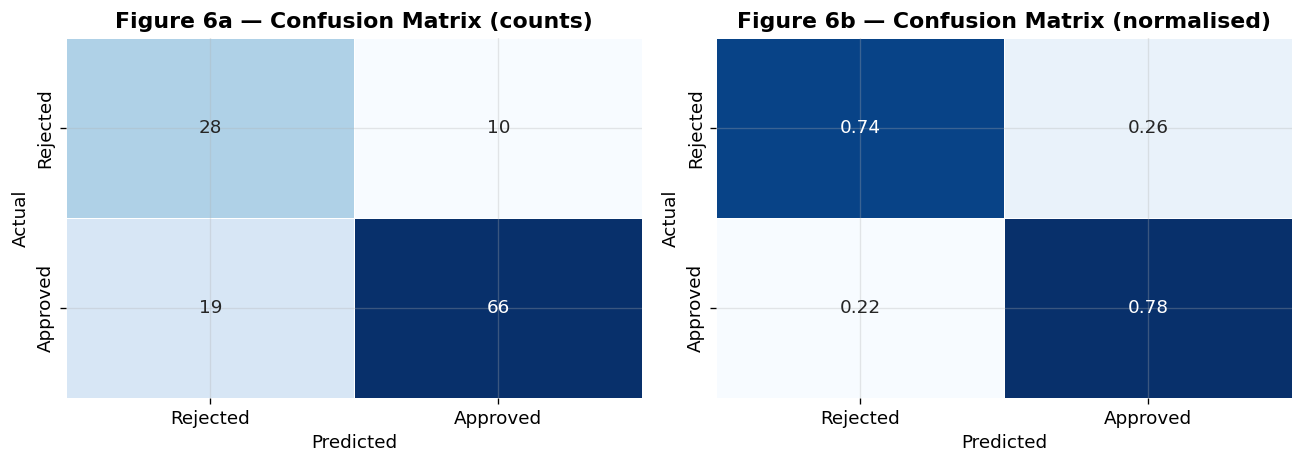

In [ ]:
# ── Figure 6: Confusion matrix ────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, data, fmt, title in [
    (axes[0], cm,      'd',    'Figure 6a — Confusion Matrix (counts)'),
    (axes[1], cm_norm, '.2f',  'Figure 6b — Confusion Matrix (normalised)')
]:
    sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=['Rejected', 'Approved'],
                yticklabels=['Rejected', 'Approved'],
                linewidths=0.5, ax=ax, cbar=False)
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')
    ax.set_title(title, fontweight='bold')
plt.tight_layout()
plt.show()

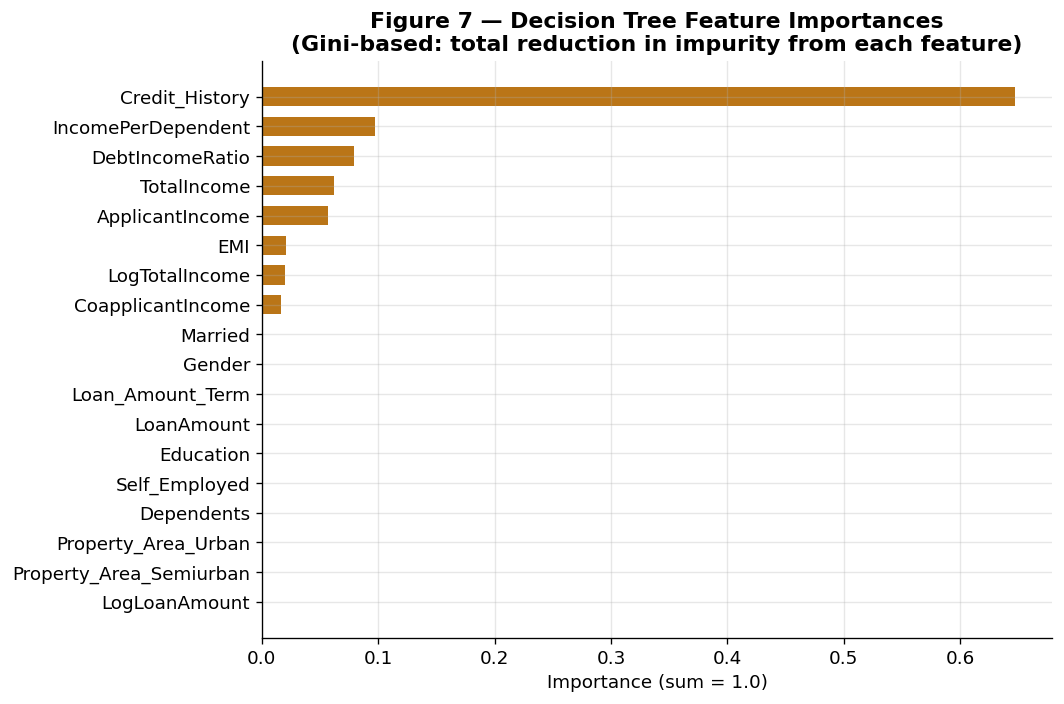

Top 5 features by Gini importance:
           Feature  Importance
    Credit_History    0.646900
IncomePerDependent    0.097446
   DebtIncomeRatio    0.079208
       TotalIncome    0.062287
   ApplicantIncome    0.057058


In [ ]:
# ── Figure 7: Feature importance ─────────────────────────────────────────────
imp_df = pd.DataFrame({
    'Feature': FEATURES,
    'Importance': dt.feature_importances_
}).sort_values('Importance', ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(imp_df['Feature'], imp_df['Importance'],
        color=AMBER, edgecolor='none', height=0.65)
ax.invert_yaxis()
ax.set_title('Figure 7 — Decision Tree Feature Importances\n'
             '(Gini-based: total reduction in impurity from each feature)',
             fontweight='bold')
ax.set_xlabel('Importance (sum = 1.0)')
plt.tight_layout()
plt.show()

print('Top 5 features by Gini importance:')
print(imp_df.head(5).to_string(index=False))

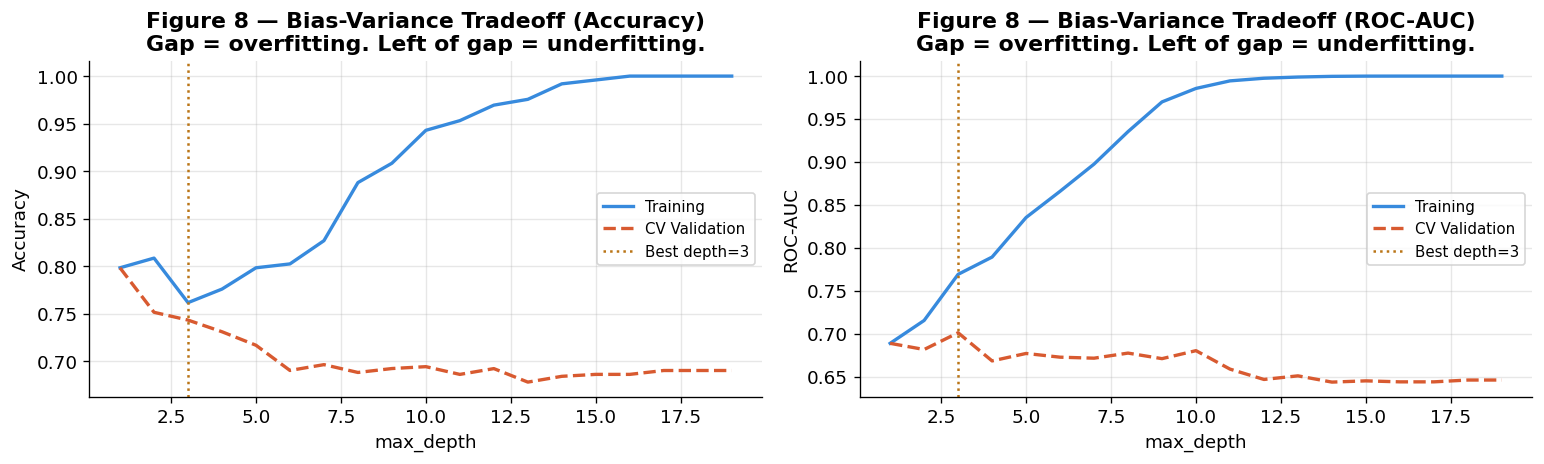

Best max_depth (by CV AUC): 3


In [ ]:
# ── Figure 8: Bias-variance tradeoff — max_depth tuning ──────────────────────
depths = range(1, 20)
train_accs, val_accs = [], []
train_aucs, val_aucs = [], []

for d in depths:
    clf = DecisionTreeClassifier(criterion='gini', max_depth=d,
                                  class_weight='balanced', random_state=42)
    clf.fit(X_train, y_train)
    train_accs.append(accuracy_score(y_train, clf.predict(X_train)))
    val_accs.append(cross_val_score(clf, X_train, y_train, cv=cv,
                                     scoring='accuracy').mean())
    train_aucs.append(roc_auc_score(y_train, clf.predict_proba(X_train)[:, 1]))
    val_aucs.append(cross_val_score(clf, X_train, y_train, cv=cv,
                                     scoring='roc_auc').mean())

best_depth = depths[np.argmax(val_aucs)]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, tr, va, metric, ylabel in [
    (axes[0], train_accs, val_accs, 'Accuracy', 'Accuracy'),
    (axes[1], train_aucs, val_aucs, 'ROC-AUC',  'ROC-AUC')
]:
    ax.plot(list(depths), tr, color=BLUE,  linewidth=2, label='Training')
    ax.plot(list(depths), va, color=CORAL, linewidth=2,
            linestyle='--', label='CV Validation')
    ax.axvline(best_depth, color=AMBER, linewidth=1.5,
                linestyle=':', label=f'Best depth={best_depth}')
    ax.set_xlabel('max_depth')
    ax.set_ylabel(ylabel)
    ax.set_title(f'Figure 8 — Bias-Variance Tradeoff ({metric})\n'
                 'Gap = overfitting. Left of gap = underfitting.',
                 fontweight='bold')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()
print(f'Best max_depth (by CV AUC): {best_depth}')

In [ ]:
# ── GridSearch: tune max_depth + min_samples_leaf ─────────────────────────────
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth':        [2, 3, 4, 5, 6, 7, 8],
    'min_samples_leaf': [1, 5, 10, 15, 20],
    'min_samples_split':[2, 10, 20]
}

grid = GridSearchCV(
    DecisionTreeClassifier(criterion='gini', class_weight='balanced',
                            random_state=42),
    param_grid=param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1
)
grid.fit(X_train, y_train)

print(f'Best parameters: {grid.best_params_}')
print(f'Best CV AUC:     {grid.best_score_:.4f}')

Best parameters: {'max_depth': 6, 'min_samples_leaf': 20, 'min_samples_split': 2}
Best CV AUC:     0.7504


Final model — Test set:
  Accuracy : 0.7642
  ROC-AUC  : 0.8615

              precision    recall  f1-score   support

    Rejected       0.58      0.84      0.69        38
    Approved       0.91      0.73      0.81        85

    accuracy                           0.76       123
   macro avg       0.75      0.79      0.75       123
weighted avg       0.81      0.76      0.77       123



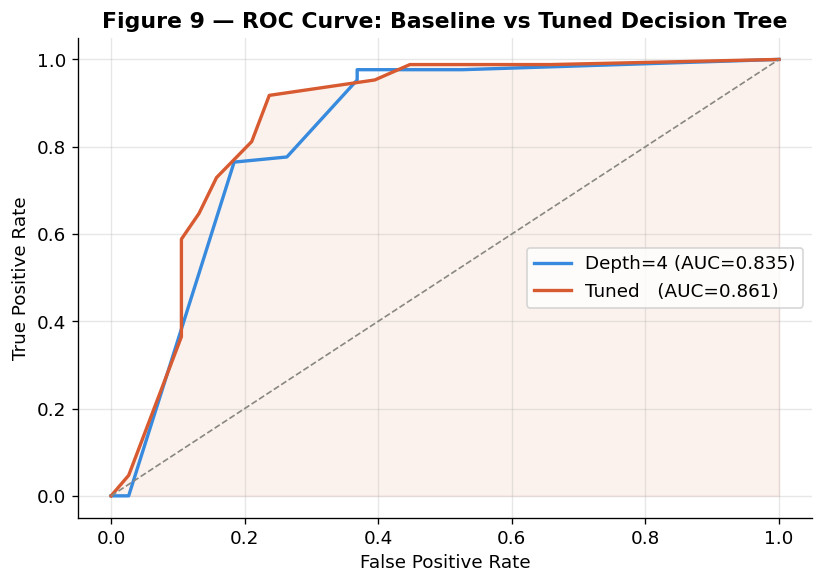

In [ ]:
# ── Final model with best parameters ─────────────────────────────────────────
dt_best = grid.best_estimator_
y_pred_best = dt_best.predict(X_test)
y_prob_best = dt_best.predict_proba(X_test)[:, 1]

print(f'Final model — Test set:')
print(f'  Accuracy : {accuracy_score(y_test, y_pred_best):.4f}')
print(f'  ROC-AUC  : {roc_auc_score(y_test, y_prob_best):.4f}')
print()
print(classification_report(y_test, y_pred_best,
                              target_names=['Rejected', 'Approved']))

# ROC curve
fpr_b, tpr_b, _ = roc_curve(y_test, y_prob_best)
fpr_i, tpr_i, _ = roc_curve(y_test, y_prob)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr_i, tpr_i, color=BLUE,  linewidth=2,
        label=f'Depth=4 (AUC={roc_auc_score(y_test, y_prob):.3f})')
ax.plot(fpr_b, tpr_b, color=CORAL, linewidth=2,
        label=f'Tuned   (AUC={roc_auc_score(y_test, y_prob_best):.3f})')
ax.plot([0,1],[0,1], color=GRAY, linewidth=1, linestyle='--')
ax.fill_between(fpr_b, tpr_b, alpha=0.08, color=CORAL)
ax.set_title('Figure 9 — ROC Curve: Baseline vs Tuned Decision Tree',
             fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend()
plt.tight_layout()
plt.show()

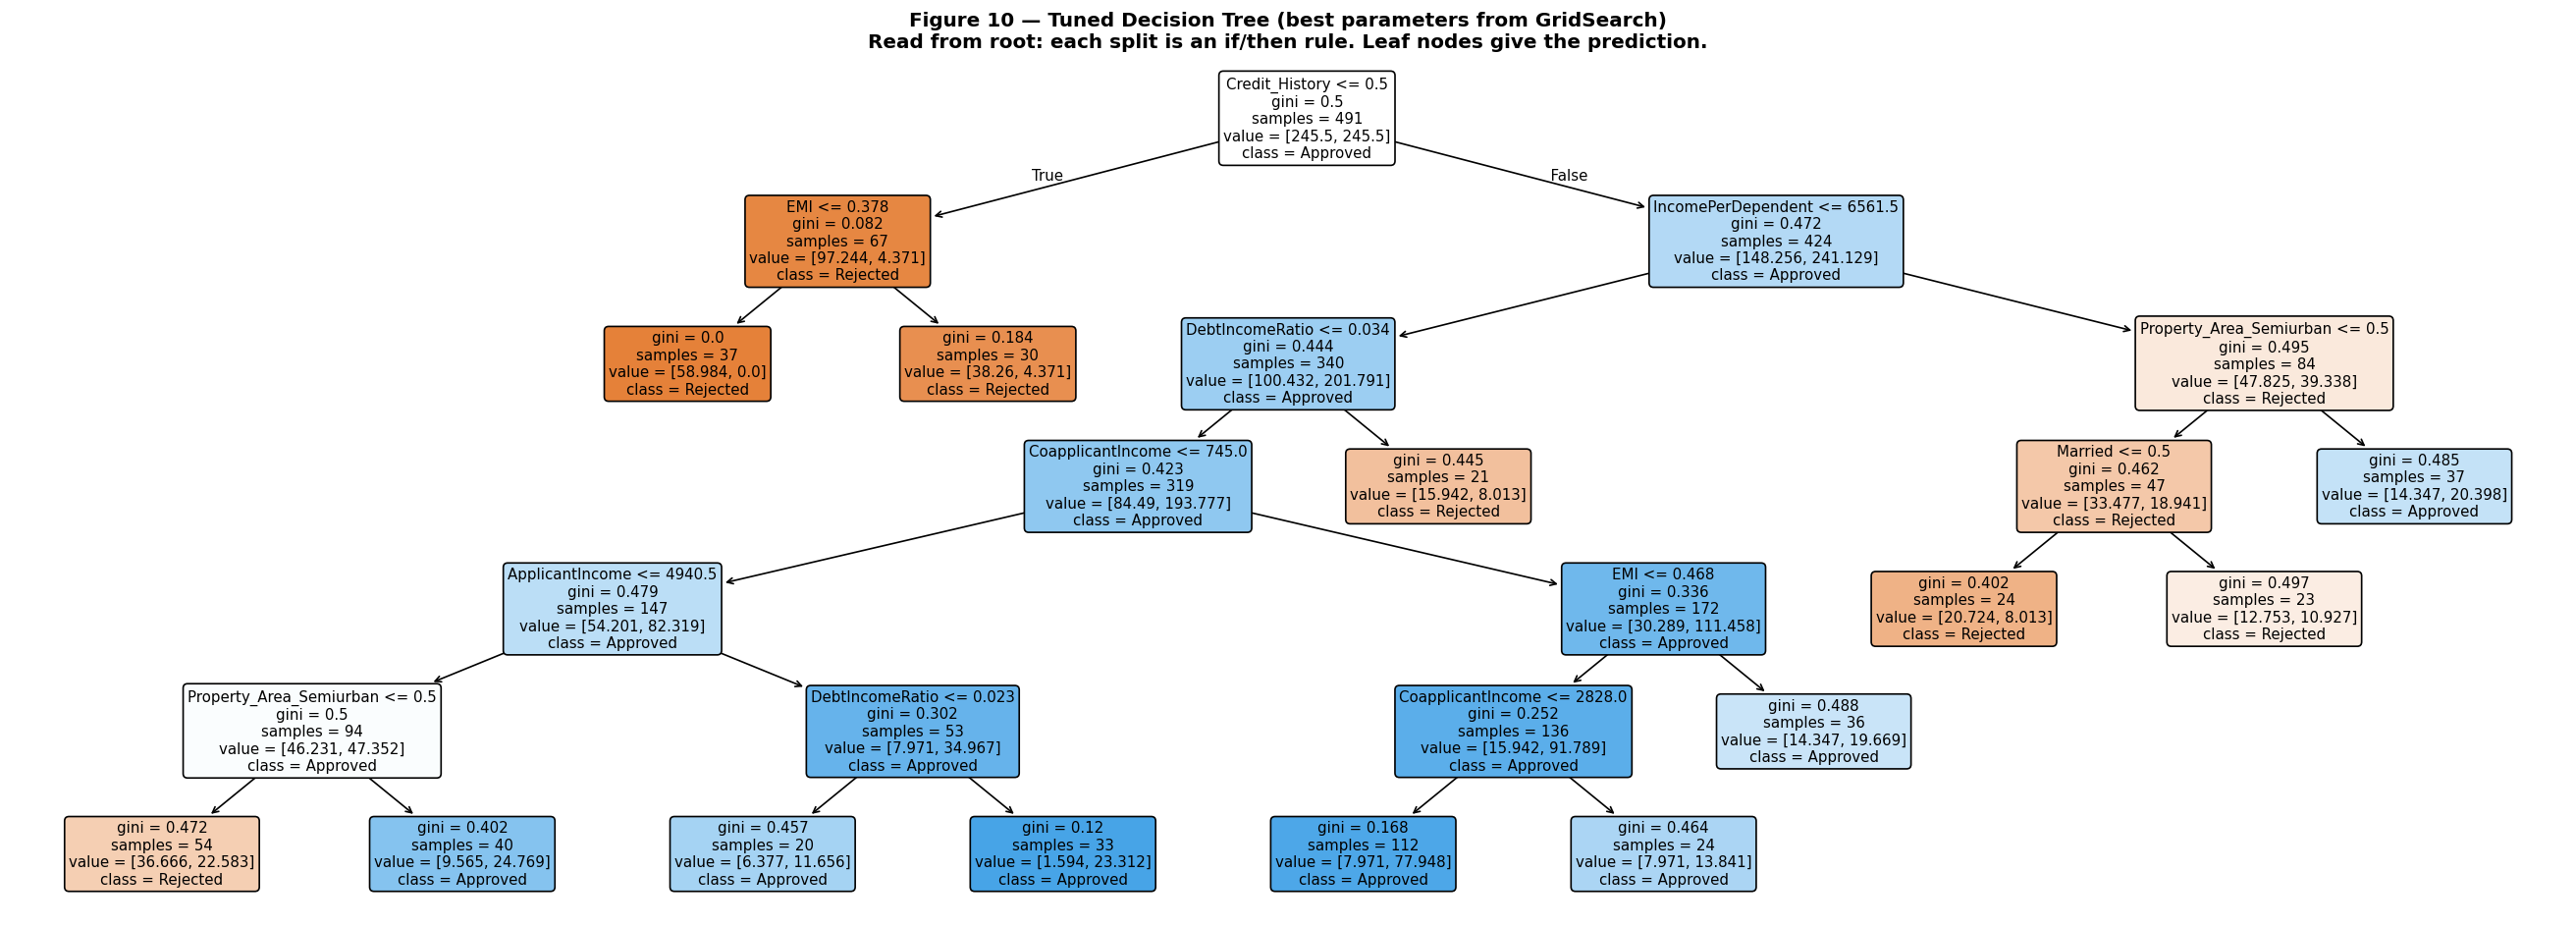

In [ ]:
# ── Figure 10: Final tuned tree visualisation ─────────────────────────────────
fig, ax = plt.subplots(figsize=(22, 8))
plot_tree(
    dt_best,
    feature_names=FEATURES,
    class_names=['Rejected', 'Approved'],
    filled=True,
    rounded=True,
    impurity=True,
    fontsize=9,
    ax=ax
)
ax.set_title('Figure 10 — Tuned Decision Tree (best parameters from GridSearch)\n'
             'Read from root: each split is an if/then rule. Leaf nodes give the prediction.',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

---
## Step 9 — PCA Extension

As discussed in the PCA notebook, decision trees are the model **least likely to benefit from PCA** because:
- Trees split on one feature at a time — correlations between features are handled by simply choosing the most informative one.
- PCA components are linear combinations of all features — this **destroys interpretability**, which is one of the main reasons we chose a decision tree in the first place.

We demonstrate this empirically: PCA is unlikely to improve (and may slightly hurt) the decision tree's performance.

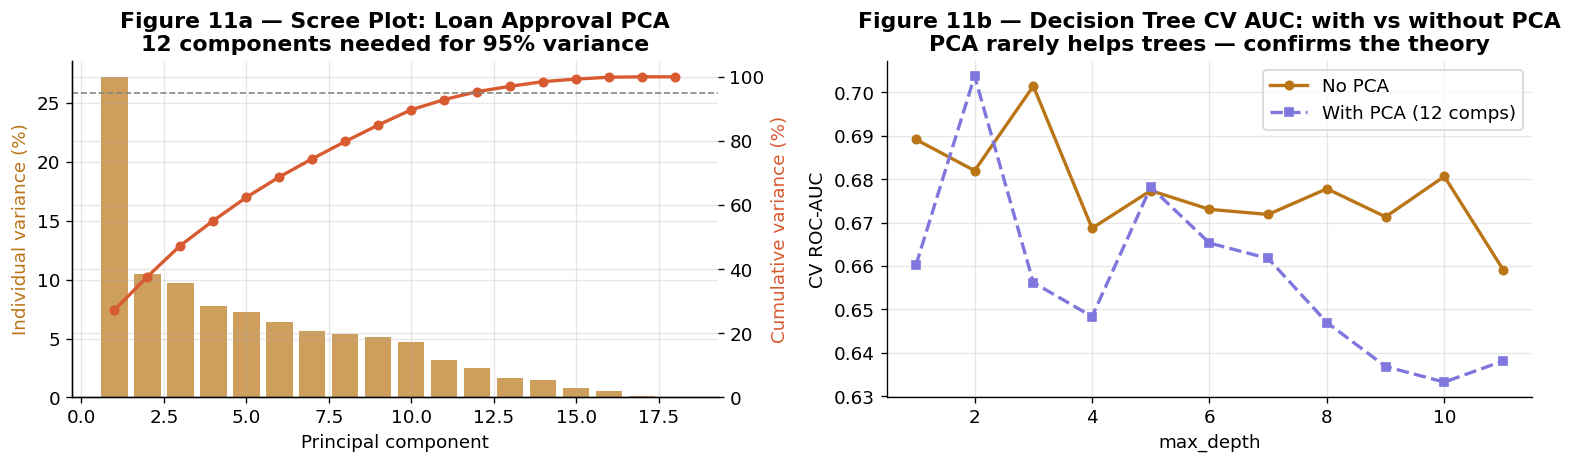

Best AUC without PCA: 0.7014
Best AUC with    PCA: 0.7037

Conclusion: PCA provides no benefit to Decision Trees.
The tree already selects the most informative features at each split.


In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Scree plot
scaler_pca = StandardScaler()
pca_full   = PCA().fit(scaler_pca.fit_transform(X_train))
evr  = pca_full.explained_variance_ratio_
cumv = np.cumsum(evr)
k_pca = np.argmax(cumv >= 0.95) + 1

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax2 = axes[0].twinx()
axes[0].bar(range(1, len(evr)+1), evr*100, color=AMBER, alpha=0.7)
ax2.plot(range(1, len(evr)+1), cumv*100, color=CORAL,
          marker='o', markersize=5, linewidth=2)
ax2.axhline(95, color=GRAY, linewidth=1, linestyle='--')
axes[0].set_title(f'Figure 11a — Scree Plot: Loan Approval PCA\n'
                   f'{k_pca} components needed for 95% variance',
                   fontweight='bold')
axes[0].set_xlabel('Principal component')
axes[0].set_ylabel('Individual variance (%)', color=AMBER)
ax2.set_ylabel('Cumulative variance (%)', color=CORAL)
ax2.set_ylim(0, 105)

# Compare AUC across depths: no-PCA vs with-PCA
val_aucs_nopca, val_aucs_pca = [], []
for d in range(1, 12):
    pipe_np = DecisionTreeClassifier(criterion='gini', max_depth=d,
                                      class_weight='balanced', random_state=42)
    pipe_pc = Pipeline([
        ('sc',  StandardScaler()),
        ('pca', PCA(n_components=k_pca)),
        ('m',   DecisionTreeClassifier(criterion='gini', max_depth=d,
                                        class_weight='balanced', random_state=42))
    ])
    val_aucs_nopca.append(cross_val_score(pipe_np, X_train, y_train,
                                           cv=cv, scoring='roc_auc').mean())
    val_aucs_pca.append(cross_val_score(pipe_pc, X_train, y_train,
                                         cv=cv, scoring='roc_auc').mean())

axes[1].plot(range(1,12), val_aucs_nopca, color=AMBER, linewidth=2,
              marker='o', markersize=5, label='No PCA')
axes[1].plot(range(1,12), val_aucs_pca,   color=PURP,  linewidth=2,
              marker='s', markersize=5, linestyle='--', label=f'With PCA ({k_pca} comps)')
axes[1].set_title('Figure 11b — Decision Tree CV AUC: with vs without PCA\n'
                   'PCA rarely helps trees — confirms the theory',
                   fontweight='bold')
axes[1].set_xlabel('max_depth')
axes[1].set_ylabel('CV ROC-AUC')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Best AUC without PCA: {max(val_aucs_nopca):.4f}')
print(f'Best AUC with    PCA: {max(val_aucs_pca):.4f}')
print('\nConclusion: PCA provides no benefit to Decision Trees.')
print('The tree already selects the most informative features at each split.')

---
## Summary

| Step | Key output |
|---|---|
| Problem | Binary classification: loan approved (1) vs rejected (0) |
| Dataset | Loan Prediction Dataset, 614 applications, 12 raw features |
| Key preprocessing | Median/mode imputation; `Dependents` '3+' → 3; binary encoding; one-hot for `Property_Area` |
| Engineered features | `TotalIncome`, `LogTotalIncome`, `LogLoanAmount`, `EMI`, `DebtIncomeRatio`, `IncomePerDependent` |
| Model chosen | **Decision Tree (Gini criterion)** |
| Core justification | Rule-based conditional decisions; handles categorical + numeric natively; no scaling needed; interpretable as explicit if/then rules |
| Split metric | Gini impurity: $1 - \sum p_k^2$, minimised at each split |
| Tuning | GridSearch over `max_depth`, `min_samples_leaf`, `min_samples_split` |
| PCA finding | No improvement — trees are inherently PCA-resistant; PCA also destroys interpretability |

**The core mathematical argument:**

At each node, the tree solves:

$$\arg\max_{j,\, t} \left[ \text{Gini}(S) - \frac{|S_L|}{|S|}\text{Gini}(S_L) - \frac{|S_R|}{|S|}\text{Gini}(S_R) \right]$$

where $j$ is the feature and $t$ is the split threshold. This greedy search is repeated recursively until `max_depth` or `min_samples_leaf` is reached.

The result is a set of **human-readable rules** — the most interpretable output of any model in this course.

---
*Next: Problem 4 — Iris Species Classification with KNN*